# Setup

## Packages

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc

# cell-cell communication
import liana as li
from liana.method import (
    singlecellsignalr,
    connectome,
    cellphonedb,
    natmi,
    logfc,
    cellchat,
    geometric_mean,
)
import cell2cell as c2c
from scipy.stats import zscore

# pathway enrichment
import decoupler as dc

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from collections import defaultdict

In [2]:
# NOTE: to use CPU instead of GPU, set use_gpu = False
use_gpu = True

if use_gpu:
    import torch
    import tensorly as tl

    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cuda":
        tl.set_backend("pytorch")
else:
    device = "cpu"

device

'cuda'

## Functions

### Scatterplots

#### Embedding shuffled

In [3]:
def embedding_shuffled(
    adata,
    basis="X_umap",
    legend_fontsize=12,
    legend_fontoutline=3,
    add_outline=False,
    frameon=False,
    size=None,
    show=False,
    *args,
    **kwargs,
):
    np.random.seed(0)
    random_indices = np.random.permutation(list(range(adata.shape[0])))

    if size is None:
        size = 150000 / adata.n_obs

    sc.pl.embedding(
        adata=adata[random_indices, :],
        basis=basis,
        legend_fontsize=legend_fontsize,
        legend_fontoutline=legend_fontoutline,
        add_outline=add_outline,
        frameon=frameon,
        size=size,
        show=show,
        *args,
        **kwargs,
    )

### Barplots

In [4]:
def get_dataframe_barplot(
    adata,
    groupby,
    color_var: str,
    *,
    normalize_groupby: bool = True,
    normalize_color_var: bool = True,
    percent: bool = True,
) -> pd.DataFrame:
    df = sc.get.obs_df(
        adata=adata,
        keys=[groupby, color_var],
    )

    df = (
        df.groupby([groupby, color_var], observed=True).size().reset_index(name="count")
    )

    if normalize_groupby:
        df["count"] = df["count"] / (
            df.groupby(groupby, observed=True)["count"].transform("sum")
        )

    if normalize_color_var:
        df["count"] = df["count"] / (
            df.groupby(color_var, observed=True)["count"].transform("sum")
        )

    if percent and (normalize_color_var or normalize_groupby):
        df["count"] *= 100

    return df.pivot(index=groupby, columns=color_var, values="count").fillna(0)

### Label spreading

In [ ]:
def spread_labels(y_positions, min_dist=50):
    y_positions = np.array(y_positions, dtype=float)
    idx_sort = np.argsort(y_positions)
    y_sorted = y_positions[idx_sort]
    y_adjusted = y_sorted.copy()

    for i in range(1, len(y_adjusted)):
        if y_adjusted[i] - y_adjusted[i - 1] < min_dist:
            y_adjusted[i] = y_adjusted[i - 1] + min_dist

    shift = np.median(y_sorted - y_adjusted)
    y_adjusted += shift

    for _ in range(10):
        for i in range(0, len(y_adjusted) - 1):
            new_y = y_adjusted[i + 1] - min_dist
            if y_adjusted[i] < new_y and new_y < y_sorted[i]:
                y_adjusted[i] = new_y
            elif y_adjusted[i] < new_y and y_sorted[i] < new_y:
                y_adjusted[i] = y_sorted[i]

    last_i = len(y_adjusted) - 1
    if y_adjusted[last_i] < y_sorted[last_i]:
        y_adjusted[last_i] = y_sorted[last_i]

    y_final = np.empty_like(y_adjusted)
    y_final[idx_sort] = y_adjusted

    return y_final

## Dataset

In [ ]:
data_path = "/path/to/data/"

adata = sc.read_h5ad(f"{data_path}human_skin_gd_lc_cleaned.h5ad")

# Ligand-Receptor inference by sample

In [ ]:
adata.X = adata.layers["log1p_norm"].copy()

In [ ]:
sample_key = "sample_id"
condition_key = "developmental_stage"
groupby = "cell_group"
group_pair = pd.DataFrame(
    {"source": ["γδ-T-cells", "LC"], "target": ["LC", "γδ-T-cells"]}
)

In [ ]:
methods = [
    logfc,
    geometric_mean,
    singlecellsignalr,
    connectome,
    cellphonedb,
    natmi,
    cellchat,
]
new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)

In [ ]:
new_rank_aggregate.by_sample(
    adata,
    sample_key=sample_key,
    groupby=groupby,
    groupby_pairs=group_pair,
    resource_name="consensus",
    min_cells=1,
    use_raw=False,
    verbose=True,
    inplace=True,
    return_all_lrs=True,
)

In [ ]:
tensor = li.multi.to_tensor_c2c(
    adata,
    sample_key=sample_key,
    score_key="magnitude_rank",
    how="outer",
)

In [34]:
context_dict = adata.obs[[sample_key, condition_key]].drop_duplicates()
context_dict = dict(zip(context_dict[sample_key], context_dict[condition_key]))
context_dict = defaultdict(lambda: "Unknown", context_dict)

In [ ]:
tensor_meta = c2c.tensor.generate_tensor_metadata(
    interaction_tensor=tensor,
    metadata_dicts=[context_dict, None, None, None],
    fill_with_order_elements=True,
)

In [ ]:
tensor = c2c.analysis.run_tensor_cell2cell_pipeline(
    tensor,
    tensor_meta,
    copy_tensor=True,
    rank=4,
    tf_optimization="robust",
    random_state=0,
    device=device,
    elbow_metric="error",
    smooth_elbow=False,
    upper_rank=10,
    tf_init="svd",
    tf_svd="numpy_svd",
    cmaps=None,
    sample_col="Element",
    group_col="Category",
    output_fig=False,
)

# Figures

In [ ]:
plt.rcParams.update(
    {
        "font.family": "Myriad Pro",
        "font.size": 8,
        "pdf.fonttype": 42,
        "axes.titlesize": "medium",
        "figure.titlesize": "medium",
        "figure.labelsize": "medium",
        "legend.fontsize": 8.0,
        "svg.fonttype": "none",
    }
)

## Colors

In [ ]:
dev_stage_colors = {"fetal": "#8c510a", "adult": "#01665e"}

cell_group_colors = {"γδ-T-cells": "#fc9627", "LC": "#9ee9c4"}

In [ ]:
sample_to_dev_stage = {
    "4820STDY7389006": "adult",
    "4820STDY7388994": "adult",
    "4820STDY7389002": "adult",
    "4820STDY7389010": "adult",
    "4820STDY7389003": "adult",
    "4820STDY7389008": "adult",
    "4820STDY7389011": "adult",
    "4820STDY7388992": "adult",
    "4820STDY7388998": "adult",
    "4820STDY7389014": "adult",
    "FCAImmP7462240": "fetal",
    "FCAImmP7316886": "fetal",
    "4834STDY7002879": "fetal",
    "FCAImmP7316896": "fetal",
    "FCAImmP7316887": "fetal",
    "4834STDY7038752": "fetal",
    "FCAImmP7352189": "fetal",
    "FCAImmP7241240": "fetal",
}

sample_colors = (
    pd.DataFrame.from_dict(sample_to_dev_stage, orient="index", columns=["dev_stage"])[
        "dev_stage"
    ]
    .map(dev_stage_colors)
    .to_dict()
)

## Factor barplots

In [165]:
factors = tensor.factors

maxp pruned
cmap pruned
post pruned
CFF  pruned
BASE dropped
DSIG dropped
GPOS pruned
GSUB pruned
Added .notdef to subset
Closing glyph list over 'GSUB': 34 glyphs before
Glyph names: ['.notdef', 'A', 'C', 'F', 'L', 'R', 'S', 'T', 'a', 'c', 'd', 'delta', 'e', 'five', 'four', 'g', 'gamma', 'hyphen', 'i', 'l', 'n', 'o', 'one', 'period', 'r', 's', 'space', 't', 'three', 'two', 'u', 'v', 'x', 'zero']
Glyph IDs:   [0, 1, 14, 15, 17, 18, 19, 20, 21, 22, 34, 36, 39, 45, 51, 52, 53, 66, 68, 69, 70, 72, 74, 77, 79, 80, 83, 84, 85, 86, 87, 89, 572, 573]
Closed glyph list over 'GSUB': 50 glyphs after
Glyph names: ['.notdef', 'A', 'C', 'F', 'L', 'R', 'S', 'T', 'a', 'c', 'd', 'delta', 'e', 'five', 'five.denominator', 'five.numerator', 'four', 'four.denominator', 'four.numerator', 'g', 'gamma', 'hyphen', 'hyphen.denominator', 'hyphen.numerator', 'i', 'l', 'n', 'o', 'one', 'one.denominator', 'one.numerator', 'period', 'period.denominator', 'period.numerator', 'r', 's', 'space', 't', 'three', 'three.d

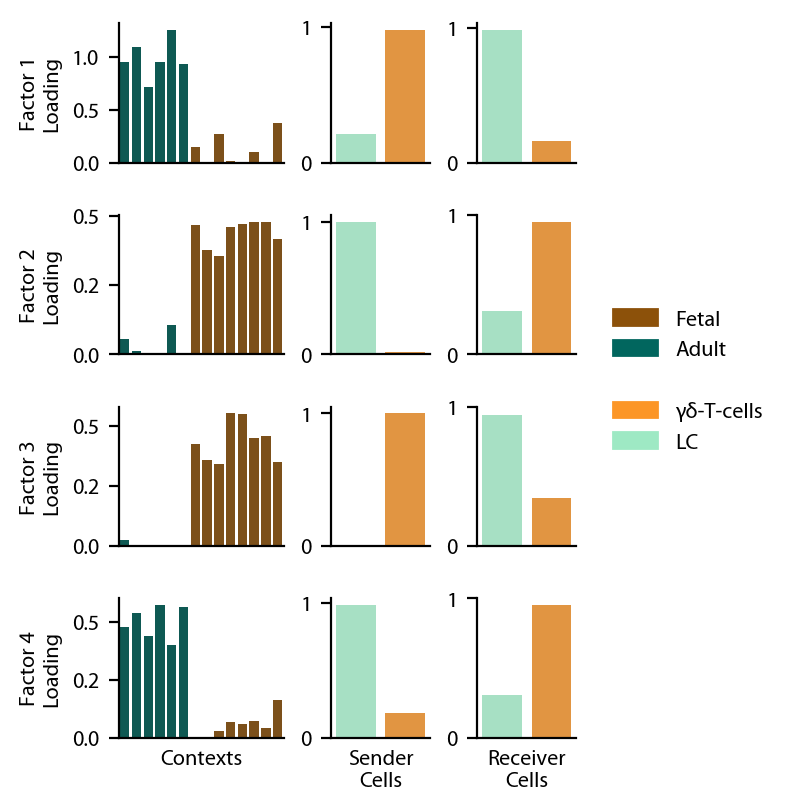

In [ ]:
factors_of_interest = [
    "Factor 1",
    "Factor 2",
    "Factor 3",
    "Factor 4",
]

contexts = tensor.factors["Contexts"].loc[:, factors_of_interest]
sender_cells = tensor.factors["Sender Cells"].loc[:, factors_of_interest]
receiver_cells = tensor.factors["Receiver Cells"].loc[:, factors_of_interest]

fig = plt.figure(figsize=(100 / 25.4, 100 / 25.4), dpi=200, layout="constrained")

gs = gridspec.GridSpec(4, 4, figure=fig, width_ratios=[2.5, 1.5, 1.5, 3])

for i, context in enumerate(contexts.keys()):
    ax = fig.add_subplot(gs[i, 0])

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

    sns.barplot(data=contexts.loc[:, context], palette=sample_colors)

    ax.set_ylabel(
        f"{context}\nLoading",
    )

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_xticklabels([])
    ax.set_xticks([])

    y_ticklabels_old = ax.get_yticklabels()
    y_ticklabels_new = []

    for label in y_ticklabels_old:
        text = label.get_text()
        new_text = round(float(text), 1)
        y_ticklabels_new.append(new_text)

    ax.set_yticklabels(y_ticklabels_new)

    if context == "Factor 4":
        ax.set_xlabel(
            "Contexts",
        )

for i, sender_cell in enumerate(sender_cells.keys()):
    ax = fig.add_subplot(gs[i, 1])

    sns.barplot(data=sender_cells.loc[:, sender_cell], palette=cell_group_colors)

    ax.set_ylabel("")
    ax.set_xlabel("")

    ax.set_xticklabels([])
    ax.set_xticks([])

    ax.set_yticks([0, 1])

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    if sender_cell == "Factor 4":
        ax.set_xlabel(
            "Sender\nCells",
        )

for i, receiver_cell in enumerate(receiver_cells.keys()):
    ax = fig.add_subplot(gs[i, 2])

    sns.barplot(data=receiver_cells.loc[:, receiver_cell], palette=cell_group_colors)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_ylabel("")
    ax.set_xlabel("")

    ax.set_xticklabels([])
    ax.set_xticks([])

    ax.set_yticks([0, 1])

    if receiver_cell == "Factor 4":
        ax.set_xlabel(
            "Receiver\nCells",
        )

legend_ax = fig.add_subplot(gs[:, 3])

timepoint_patches = [
    mpatches.Patch(color=color, label=label.capitalize())
    for label, color in dev_stage_colors.items()
]

celltype_patches = [
    mpatches.Patch(color=color, label=label)
    for label, color in cell_group_colors.items()
]

legend_ax.axis("off")

legend_ax.legend(
    handles=(
        timepoint_patches + [mpatches.Patch(color="none", label="")] + celltype_patches
    ),
    title=None,
    loc="center left",
    frameon=False,
)

plt.show()

## Heatmaps

### Heatmap handpicked interactions

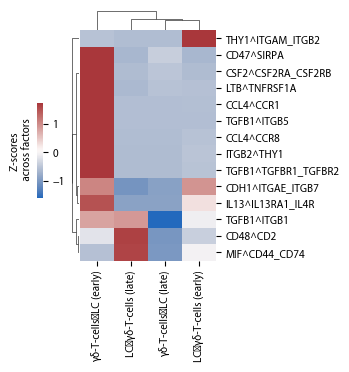

In [ ]:
factors_of_interest = ["Factor 1", "Factor 2", "Factor 3", "Factor 4"]
factor_to_ticklabel = {
    "Factor 1": "γδ-T-cells→LC (late)",
    "Factor 2": "LC→γδ-T-cells (early)",
    "Factor 3": "γδ-T-cells→LC (early)",
    "Factor 4": "LC→γδ-T-cells (late)",
}

loadings_of_interest = [
    "ITGB2^THY1",
    "CDH1^ITGAE_ITGB7",
    "CD48^CD2",
    "CCL4^CCR8",
    "CCL4^CCR1",
    "TGFB1^TGFBR1_TGFBR2",
    "LTB^TNFRSF1A",
    "TGFB1^ITGB5",
    "THY1^ITGAM_ITGB2",
    "CD47^SIRPA",
    "TGFB1^ITGB1",
    "MIF^CD44_CD74",
    "IL13^IL13RA1_IL4R",
    "CSF2^CSF2RA_CSF2RB",
]

p1 = c2c.plotting.loading_clustermap(
    loadings=tensor.factors["Ligand-Receptor Pairs"].loc[
        loadings_of_interest,
        factors_of_interest,
    ],
    loading_threshold=0,
    use_zscore=True,
    figsize=(78.264 / 25.4, 80 / 25.4),
    row_cluster=True,
    dendrogram_ratio=0.15,
    method="ward",
    axis_zscore=1,
    heatmap_lw=0,
    cbar_pos=(-0.02, 0.3, 0.02, 0.3),
    cmap="vlag",
)

labels = []

for label in p1.ax_heatmap.get_xticklabels():
    labels.append(factor_to_ticklabel[label.get_text()])

p1.ax_heatmap.set_xticklabels(labels, rotation=90, ha="center")

plt.show()

In [ ]:
# Overall UMAP plot sizes, width gets changed if legend is added
plot_width_in = 53 / 25.4
plot_height_in = 99 / 25.4
# Margin around plot area in inches
margin_left = 0
margin_right = 0
margin_bottom = 0
margin_top = 0

# Legend spacer in inches
legend_width_in = 0

maxp pruned
cmap pruned
post pruned
CFF  pruned
BASE dropped
DSIG dropped
GPOS pruned
GSUB pruned
Missing glyphs for requested Unicodes: ['U+2192']
Added .notdef to subset
Closing glyph list over 'GSUB': 26 glyphs before
Glyph names: ['.notdef', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'Y', 'eight', 'five', 'four', 'one', 'seven', 'three', 'two', 'underscore']
Glyph IDs:   [0, 18, 19, 20, 21, 22, 24, 25, 34, 35, 36, 37, 38, 39, 40, 41, 42, 45, 46, 47, 49, 51, 52, 53, 58, 64]
Closed glyph list over 'GSUB': 40 glyphs after
Glyph names: ['.notdef', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'Y', 'eight', 'eight.denominator', 'eight.numerator', 'five', 'five.denominator', 'five.numerator', 'four', 'four.denominator', 'four.numerator', 'one', 'one.denominator', 'one.numerator', 'seven', 'seven.denominator', 'seven.numerator', 'three', 'three.denominator', 'three.numerator', 'two', 'two.denominator', 'two.numerator',

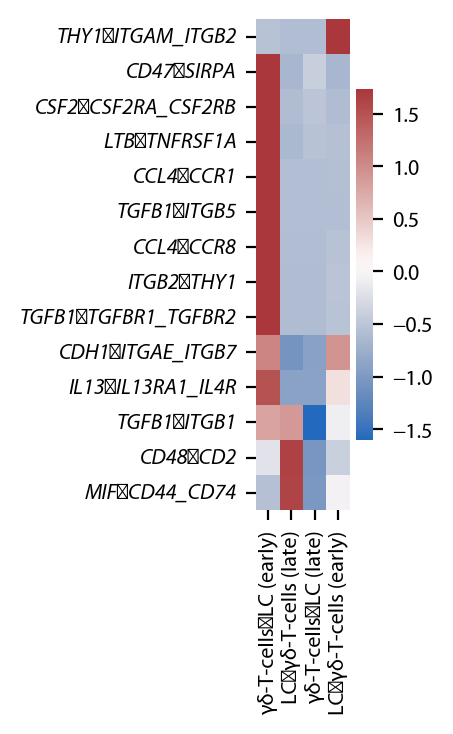

In [ ]:
fig_width = margin_left + plot_width_in + legend_width_in + margin_right
fig_height = margin_bottom + plot_height_in + margin_top

fig, axes = plt.subplots(
    figsize=(fig_width, fig_height),
    dpi=200,
)

sns.heatmap(
    p1.data2d,
    cmap="vlag",
)

labels = []

for label in axes.get_xticklabels():
    labels.append(factor_to_ticklabel[label.get_text()])

axes.set_xticklabels(labels, rotation=90, ha="center")

labels = []
for label in axes.get_yticklabels():
    labels.append(label.get_text().replace("^", "→"))
    label.set_style("italic")

axes.set_yticklabels(
    labels,
    rotation=0,
)

fig.subplots_adjust(
    left=0.57,
    right=0.85,
    bottom=0.35,
    top=0.98,
)

### Heatmap top 500

In [ ]:
lr_of_interest = (
    tensor.factors["Ligand-Receptor Pairs"]
    .reset_index()
    .melt(id_vars=["index"], var_name="Factor", value_name="Value")
    .sort_values("Value", ascending=False)
    .drop_duplicates("index")
    .head(500)
    .loc[:, "index"]
    .to_list()
)

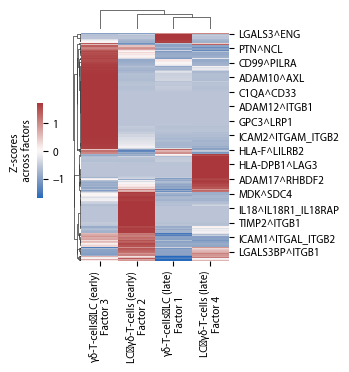

In [ ]:
factors_of_interest = ["Factor 1", "Factor 2", "Factor 3", "Factor 4"]
factor_to_ticklabel = {
    "Factor 1": "γδ-T-cells→LC (late)\nFactor 1",
    "Factor 2": "LC→γδ-T-cells (early)\nFactor 2",
    "Factor 3": "γδ-T-cells→LC (early)\nFactor 3",
    "Factor 4": "LC→γδ-T-cells (late)\nFactor 4",
}

p1_top_500 = c2c.plotting.loading_clustermap(
    loadings=tensor.factors["Ligand-Receptor Pairs"].loc[
        lr_of_interest,
        factors_of_interest,
    ],
    loading_threshold=0,
    use_zscore=True,
    figsize=(78.264 / 25.4, 80 / 25.4),
    row_cluster=True,
    dendrogram_ratio=0.15,
    method="ward",
    axis_zscore=1,
    heatmap_lw=0,
    cbar_pos=(-0.02, 0.3, 0.02, 0.3),
    cmap="vlag",
)

labels = []

for label in p1_top_500.ax_heatmap.get_xticklabels():
    labels.append(factor_to_ticklabel[label.get_text()])

p1_top_500.ax_heatmap.set_xticklabels(labels, rotation=90, ha="center")

plt.show()

In [ ]:
data_top_500 = p1_top_500.data2d

key_interactions = [
    "CALR^ITGAV",
    "SPP1^ITGAV_ITGB5",
    "SPP1^ITGAV_ITGB1",
    "ICAM1^ITGAM_ITGB2",
    "ICAM1^ITGAL_ITGB2",
    "THBS1^ITGA4",
    "COL1A1^ITGA5",
    "COL1A1^CD44",
    "COL1A2^CD44",
    "TNF^TNFRSF1A",
    "TNF^TNFRSF1B",
    "LTA^TNFRSF1A",
    "TNFSF12^TNFRSF12A",
    "JAG1^NOTCH2",
    "ADAM10^NOTCH2",
    "PSEN1^NOTCH2",
    "MFNG^NOTCH2",
    "TGFB1^TGFBR1_TGFBR2",
    "TGFB1^ITGB5",
    "TGFB1^ENG",
    "CCL5^CCR5",
    "CXCL12^CXCR4",
    "CCL19^CCR7",
    "CD47^SIRPA",
    "MIF^CD74_CXCR4",
    "HLA-DRA^CD4",
    "HLA-DPA1^LAG3",
    "APP^CD74",
    "CD86^CD28",
]

y_positions = []

for gene in key_interactions:
    y_positions.append(data_top_500.index.get_loc(gene))

y_positions = np.array(y_positions)

In [95]:
y_final = spread_labels(y_positions, min_dist=20)

maxp pruned
cmap pruned
post pruned
CFF  pruned
BASE dropped
DSIG dropped
GPOS pruned
GSUB pruned
Missing glyphs for requested Unicodes: ['U+2192']
Added .notdef to subset
Closing glyph list over 'GSUB': 33 glyphs before
Glyph names: ['.notdef', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'X', 'eight', 'five', 'four', 'hyphen', 'nine', 'one', 'seven', 'six', 'three', 'two', 'underscore', 'zero']
Glyph IDs:   [0, 14, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 49, 51, 52, 53, 55, 57, 64]
Closed glyph list over 'GSUB': 55 glyphs after
Glyph names: ['.notdef', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'X', 'eight', 'eight.denominator', 'eight.numerator', 'five', 'five.denominator', 'five.numerator', 'four', 'four.denominator', 'four.numerator', 'hyphen', 'hyphen.denominator', 'hyphen.numerator', 'nine', 'nine.denominator', 'nine.numera

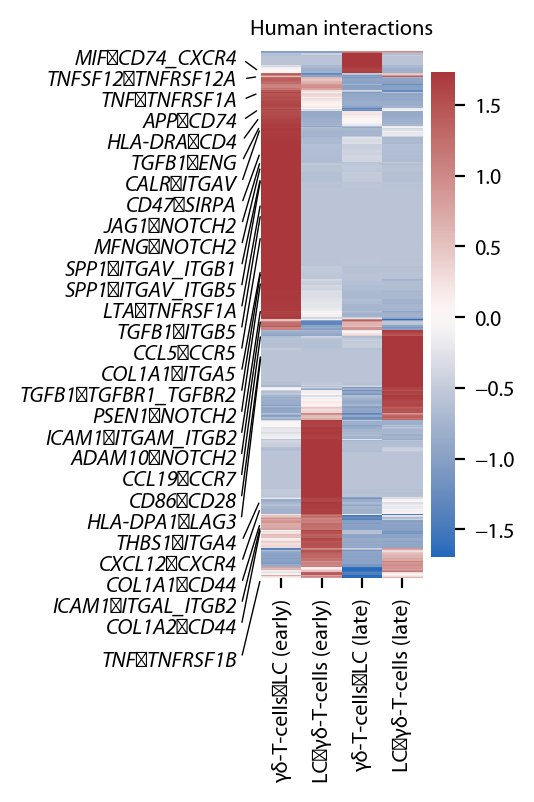

In [ ]:
fig, axes = plt.subplots(
    figsize=(65.5 / 25.4, 99 / 25.4), dpi=200, layout="constrained"
)

sns.heatmap(
    p1_top_500.data2d,
    cmap="vlag",
)

labels = []

for label in axes.get_xticklabels():
    labels.append(factor_to_ticklabel[label.get_text()])

axes.set_xticklabels(labels, rotation=90, ha="center")

axes.set_yticks([])
axes.set_yticklabels([])

for orig, shifted, label in zip(y_positions, y_final, key_interactions):
    tx, ty = -0.6, shifted + 80
    axes.text(
        tx,
        ty,
        label.replace("^", "→"),
        ha="right",
        va="center",
        fontsize=8,
        style="italic",
    )

    axes.annotate(
        "",
        xy=(0, orig),
        xytext=(tx + 0.1, ty),
        xycoords="data",
        textcoords="data",
        arrowprops=dict(arrowstyle="-", lw=0.5, color="black", connectionstyle="arc3"),
    )

axes.set_title("Human interactions")

### Heatmap top 10

In [ ]:
lr_of_interest = (
    tensor.factors["Ligand-Receptor Pairs"]
    .reset_index()
    .melt(id_vars=["index"], var_name="Factor", value_name="Value")
    .groupby("Factor")
    .apply(lambda x: x.nlargest(10, "Value"))
    .reset_index(drop=True)
    .loc[:, "index"]
    .unique()
    .tolist()
)

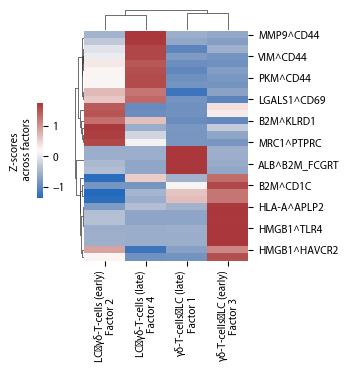

In [ ]:
factors_of_interest = ["Factor 1", "Factor 2", "Factor 3", "Factor 4"]
factor_to_ticklabel = {
    "Factor 1": "γδ-T-cells→LC (late)\nFactor 1",
    "Factor 2": "LC→γδ-T-cells (early)\nFactor 2",
    "Factor 3": "γδ-T-cells→LC (early)\nFactor 3",
    "Factor 4": "LC→γδ-T-cells (late)\nFactor 4",
}

p1_top_10 = c2c.plotting.loading_clustermap(
    loadings=tensor.factors["Ligand-Receptor Pairs"].loc[
        lr_of_interest,
        factors_of_interest,
    ],
    loading_threshold=0,
    use_zscore=True,
    figsize=(78.264 / 25.4, 80 / 25.4),
    row_cluster=True,
    dendrogram_ratio=0.15,
    method="ward",
    axis_zscore=1,
    heatmap_lw=0,
    cbar_pos=(-0.02, 0.3, 0.02, 0.3),
    cmap="vlag",
)

labels = []

for label in p1_top_10.ax_heatmap.get_xticklabels():
    labels.append(factor_to_ticklabel[label.get_text()])

p1_top_10.ax_heatmap.set_xticklabels(labels, rotation=90, ha="center")

plt.show()

In [ ]:
# Overall UMAP plot sizes, width gets changed if legend is added
plot_width_in = 184 / 25.4
plot_height_in = 50 / 25.4
# Margin around plot area in inches
margin_left = 0
margin_right = 0
margin_bottom = 0
margin_top = 0

# Legend spacer in inches
legend_width_in = 0

maxp pruned
cmap pruned
post pruned
CFF  pruned
BASE dropped
DSIG dropped
GPOS pruned
GSUB pruned
Missing glyphs for requested Unicodes: ['U+2192']
Added .notdef to subset
Closing glyph list over 'GSUB': 31 glyphs before
Glyph names: ['.notdef', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'O', 'P', 'R', 'S', 'T', 'V', 'X', 'eight', 'four', 'hyphen', 'nine', 'one', 'seven', 'six', 'three', 'two', 'underscore', 'zero']
Glyph IDs:   [0, 14, 17, 18, 19, 20, 21, 23, 24, 25, 26, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 48, 49, 51, 52, 53, 55, 57, 64]
Closed glyph list over 'GSUB': 51 glyphs after
Glyph names: ['.notdef', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'O', 'P', 'R', 'S', 'T', 'V', 'X', 'eight', 'eight.denominator', 'eight.numerator', 'four', 'four.denominator', 'four.numerator', 'hyphen', 'hyphen.denominator', 'hyphen.numerator', 'nine', 'nine.denominator', 'nine.numerator', 'one', 'one.denominator', 'one.numerator', 'seven', 'seven.denomin

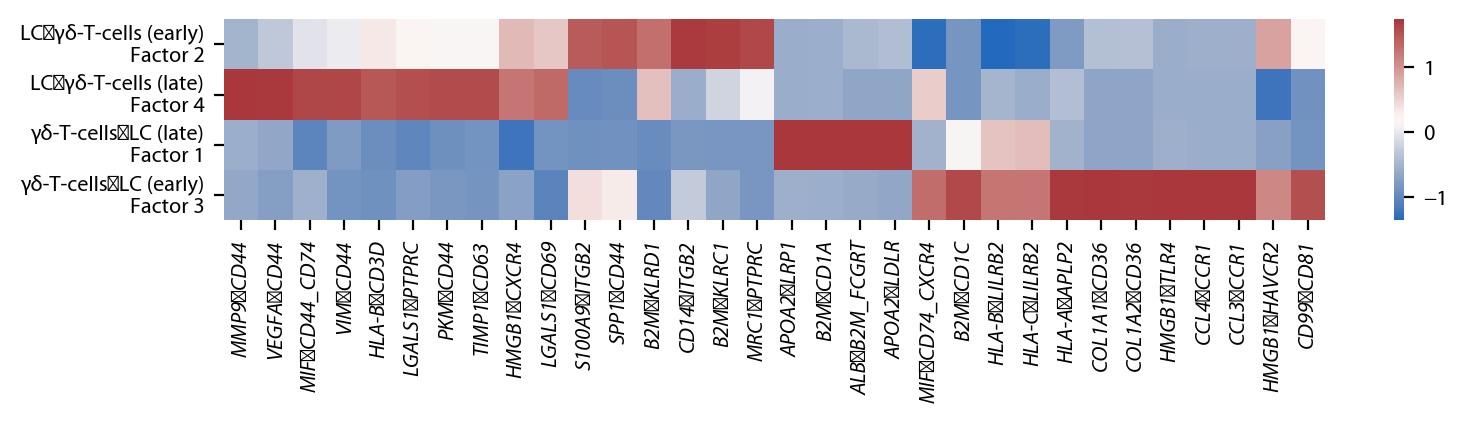

In [ ]:
fig_width = (
    margin_left + plot_width_in + legend_width_in + margin_right
)
fig_height = margin_bottom + plot_height_in + margin_top

fig, axes = plt.subplots(
    figsize=(fig_width, fig_height),
    dpi=200,
)

sns.heatmap(
    p1_top_10.data2d.T,
    cmap="vlag",
)

labels = []

for label in axes.get_yticklabels():
    labels.append(factor_to_ticklabel[label.get_text()])

axes.set_yticklabels(labels, rotation=0, ha="right")

labels = []
for label in axes.get_xticklabels():
    labels.append(label.get_text().replace("^", "→"))
    label.set_style("italic")

axes.set_xticklabels(
    labels,
    rotation=90,
)

fig.subplots_adjust(
    left=0.15,
    right=1.1,
    bottom=0.47,
    top=0.98,
)